# DATA CLEANING & PREPROCESSING

In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
import numpy as np

### Configurations

In [2]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 30 # 50

### Data fetching
- Only give tha parent folder name ( Eg : data folde has 3 folders class_1, class_2, class_3 each class folder has own images)
- Auto set the label as the folder name of that particular image in

In [3]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "data",
    shuffle=True,
    image_size = IMAGE_SIZE,
    batch_size= BATCH_SIZE,
)

Found 2152 files belonging to 3 classes.


In [4]:
class_names = dataset.class_names
class_names

['Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']

In [47]:
import json

with open("../api/class_names.json", "w") as f:
    json.dump(dataset.class_names, f)

In [5]:
len(dataset) # Why 68 - It is due to batch size 32, dataset contain  68, 32 size batches but last batch doesn not have 32

68

### Showing one image

In [6]:
type(dataset)

tensorflow.python.data.ops.prefetch_op._PrefetchDataset

In [7]:
for i in dataset.take(1):
    # print (i[0][0]) # First image
    print (i[1][0]) # First label
    print(len(i))
    print(len(i[0]))
    print(len(i[1]))

tf.Tensor(0, shape=(), dtype=int32)
2
32
32


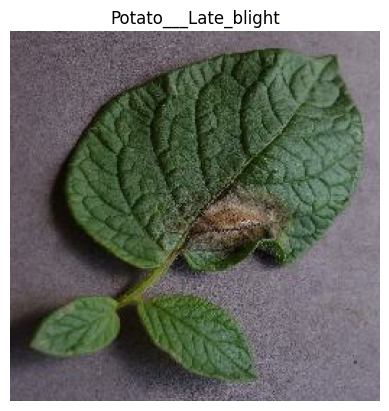

In [8]:
# dataset is collection of 68 batches each batch contain of 32 images + 32 label as seperate two lists

for img_batch, label_batch in dataset.take(1):
    # print (i[0][0]) # First image
    plt.imshow(img_batch[0].numpy().astype('uint8')) # First batch first image show
    plt.title(class_names[label_batch[0]])
    plt.axis('off')

### Showing multiple images

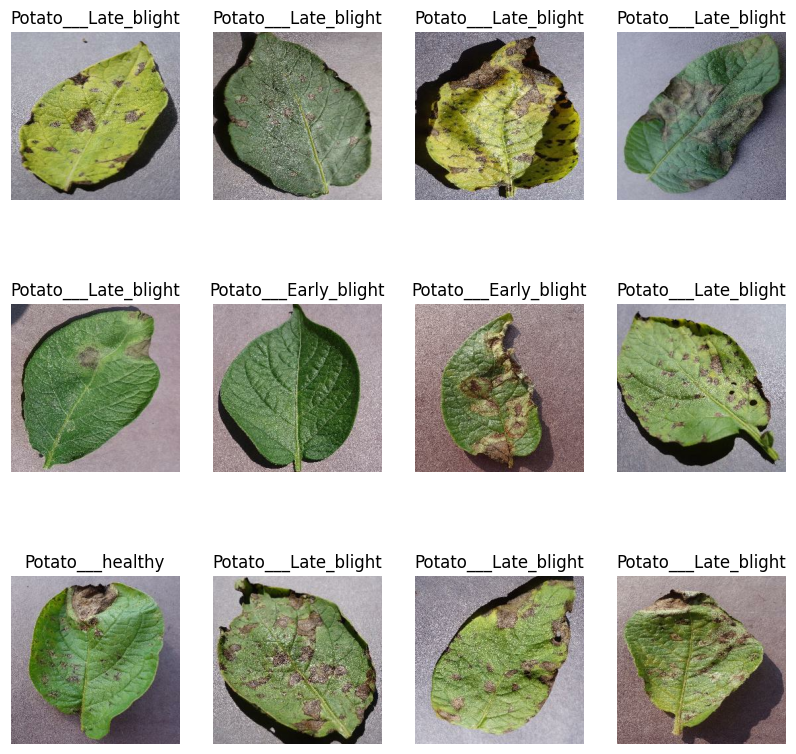

In [9]:
plt.figure(figsize=(10, 10))

for img_batch, lable_batch in dataset.take(1):
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(img_batch[i].numpy().astype('uint8'))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')

### Train test splitting

80% ==> training<br>
20% ==> 10% validation 10% testing

In [10]:
train_size = int(len(dataset)*0.8)
train_size

54

In [11]:
train_ds = dataset.take(train_size)
print(len(train_ds))
      
test_val_ds = dataset.skip(train_size)
print(len(test_val_ds))

54
14


In [12]:
val_size =int(len(dataset)* 0.1)
val_size

6

In [13]:
val_ds = test_val_ds.take(val_size)
len(val_ds)

6

In [14]:
test_ds = test_val_ds.skip(val_size)
len(test_ds)

8

In [15]:
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=1500):

    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=123)
        
    ds_size = int(len(ds))
    train_size = int(ds_size*train_split)
    val_size = int(ds_size*val_split)
    # rest of part for test
    
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [16]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

print(len(train_ds))
print(len(val_ds))
print(len(test_ds))

54
6
8


In [17]:
'''
*** cache() : Stores the dataset in memory after loading it once.
    - First epoch -> loads from disk
    - Next epochs -> uses memory (faster)

*** What is buffer size? While the model is training on Batch 1 : 
    - GPU training on Batch 1
    - CPU preparing Batch 2
    The prepared batches are stored in a temporary area called a buffer, Example: prefetch(2) > Keep 2 batches ready in advance

*** AUTOTUNE lets TensorFlow automatically choose the best buffer size
'''

'\n*** cache() : Stores the dataset in memory after loading it once.\n    - First epoch -> loads from disk\n    - Next epochs -> uses memory (faster)\n\n*** What is buffer size? While the model is training on Batch 1 : \n    - GPU training on Batch 1\n    - CPU preparing Batch 2\n    The prepared batches are stored in a temporary area called a buffer, Example: prefetch(2) > Keep 2 batches ready in advance\n\n*** AUTOTUNE lets TensorFlow automatically choose the best buffer size\n'

In [18]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size = tf.data.AUTOTUNE)

### Scaling, we will supply this layer when building the model

In [19]:
resize_rescale_layer = tf.keras.Sequential([
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE), # ensure 256 x 256
    layers.Rescaling(1.0/255) # 0 - 1
])

### Data Augmentation
- Data augmentation is a technique used to increase the diversity of training data by applying random transformations to images
- Instead of collecting new images, we create modified versions of existing images

In [20]:
data_augmentation_layer = tf.keras.Sequential([
    # Randomly flips images : left <-> right (horizontal) & up <-> down (vertical), Ex : Cat facing left -> flipped cat facing right
    layers.RandomFlip('horizontal_and_vertical'),

    # Randomly rotates the image -> 0.2 means up to 20% of 360 -> nearly ±72 degrees
    layers.RandomRotation(0.2)
])

## CNN Model
In TensorFlow
- **input shape** of the image must be defined in the first Conv layer only
- Other Conv layers we no need to define **input shape**
- all Conv layers must define the **activation fucntion** , **kernel size** & **output cahnnels**

### Note
- Here, model already expects raw 0–255 images as input, and it will internally convert them to 0–1
- So then when we do prediction through the Postman / FastAPI / Flutter backend > should pass RAW image (0–255 pixel range), NOT manually scaled 0–1
- Because your model pipeline already does this :<br>
Input image (0–255)<br>
        ↓<br>
Resizing (256x256)<br>
        ↓<br>
Rescaling (÷255 → 0–1)<br>
        ↓<br>
CNN layers

- if we manually scale before sending, double scaling happen
- 0–1 input > model rescales again (÷255) > becomes 0–0.0039 > prediction breaks

**When using this trained model images must be in 256 x 256 size & not scaled to 0-1 keep original 0-255 before doing predictions**

In [21]:
# OLD BROKEN MODEL STILL IN MEMORY (MOST COMMON) TensorFlow keeps graph state
tf.keras.backend.clear_session()

In [ ]:
input_shape = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)
n_classes = int(len(class_names))

# padding="same" = keep image size same by adding pdding if conv input 256 out 256 to poolling layer
# since polling kernel 2, 2 it create single value for each 2x2 metrix then size reduce by half
# dont add more poilling that reduse size over the kernel size
model = models.Sequential([
    layers.Input(shape=input_shape), # 256
    resize_rescale_layer,
    data_augmentation_layer,
    layers.Conv2D(filters=64, padding="same", kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)), # 128

    layers.Conv2D(filters=64, padding="same", kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)), # 64
    
    layers.Conv2D(filters=64, padding="same", kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)), # 32

    layers.Conv2D(filters=64, padding="same", kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)), # 16

    layers.Conv2D(filters=64, padding="same", kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)), # 8

    # Flatten
    layers.Flatten(),

    # Dense layer input is 2304 these all weights connects all 64 neurons (Dense layer = Fully connected layer) 2304 x 64 + 64 bias = 147,520 
    # not good so in modern approach is to use GlobalAveragePolling2D()
    layers.Dense(units=64, activation='relu'),
    layers.Dense(n_classes, activation='softmax')
])

# No need to manually build the model

In [28]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ sequential (Sequential)              │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential_1 (Sequential)            │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_15 (Conv2D)                   │ (None, 254, 254, 64)        │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 127, 127, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 125, 125, 64)        │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 60, 60, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_18 (Conv2D)                   │ (None, 28, 28, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_18 (MaxPooling2D)      │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_19 (Conv2D)                   │ (None, 12, 12, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_19 (MaxPooling2D)      │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_3 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 297,219 (1.13 MB)

 Trainable params: 297,219 (1.13 MB)

 Non-trainable params: 0 (0.00 B)

### Compile
- It is basically where you tell TensorFlow : HOW the model should learn
- **adam** : 
    - Learning method of the model
    - Smart version of gradient descent
    - Learns faster than normal SGD
- **CategoricalCrossentrop**y : one-hot labels
- **SparseCategoricalCrossentropy** : integer labels, we use labels as 0, 1, 2
- **from_logits=False**
  - Logits = raw model outputs (before activation)
  - Softmax converts logits into probabilities where all sum = 1
  - if output not wnr thorugh softmax we can True it here but we already done it so here it is False
- **metrics=['accuracy']** : want to track > How many predictions are correct?

In [29]:
model.compile(
    optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

### Train the the model with train data

In [30]:
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
    validation_data=val_ds
)

Epoch 1/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.5452 - loss: 0.8339 - val_accuracy: 0.6719 - val_loss: 0.6937
Epoch 2/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 107s 2s/step - accuracy: 0.7705 - loss: 0.5743 - val_accuracy: 0.8490 - val_loss: 0.4516
Epoch 3/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 83s 2s/step - accuracy: 0.8357 - loss: 0.4161 - val_accuracy: 0.8854 - val_loss: 0.3583
Epoch 4/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 84s 2s/step - accuracy: 0.8486 - loss: 0.3688 - val_accuracy: 0.9010 - val_loss: 0.3629
Epoch 5/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9266 - loss: 0.1900 - val_accuracy: 0.9323 - val_loss: 0.1479
Epoch 6/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.9178 - loss: 0.2001 - val_accuracy: 0.9375 - val_loss: 0.1475
Epoch 7/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9484 - loss: 0.1240 - val_accuracy: 0.9062 - val_loss: 0.2823
Epoch 8/30
54/54 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9589 - loss: 0.1089 - val_accuracy: 0.9740 - val_los

### Evaluation

In [31]:
scores = model.evaluate(test_ds)

8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 310ms/step - accuracy: 0.9961 - loss: 0.0133


In [32]:
scores # 1st is loss, 2nd is acc

[0.013332001864910126, 0.99609375]

In [33]:
history

In [34]:
history.params

# steps = number of batches per epoch

{'verbose': 1, 'epochs': 30, 'steps': 54}

In [35]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

In [36]:
history.history['accuracy'] # All accracies we got in training

[0.545187771320343,
 0.7705398797988892,
 0.8356807231903076,
 0.8485915660858154,
 0.9266431927680969,
 0.9178403615951538,
 0.9483568072319031,
 0.9589201807975769,
 0.9606807231903076,
 0.92136150598526,
 0.9219483733177185,
 0.9419013857841492,
 0.9600939154624939,
 0.9747652411460876,
 0.9759389758110046,
 0.9671361446380615,
 0.9759389758110046,
 0.9730046987533569,
 0.9700704216957092,
 0.9841549396514893,
 0.9759389758110046,
 0.9865023493766785,
 0.9730046987533569,
 0.9659624695777893,
 0.9882628917694092,
 0.9853286147117615,
 0.9876760840415955,
 0.9618544578552246,
 0.9847418069839478,
 0.9888497591018677]

### Plotting accuracies in graph
- Get idea about overfit OR underfit

In [37]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

In [59]:
print("ACC : ", acc)
print("val_acc : ", val_acc)

ACC :  [0.545187771320343, 0.7705398797988892, 0.8356807231903076, 0.8485915660858154, 0.9266431927680969, 0.9178403615951538, 0.9483568072319031, 0.9589201807975769, 0.9606807231903076, 0.92136150598526, 0.9219483733177185, 0.9419013857841492, 0.9600939154624939, 0.9747652411460876, 0.9759389758110046, 0.9671361446380615, 0.9759389758110046, 0.9730046987533569, 0.9700704216957092, 0.9841549396514893, 0.9759389758110046, 0.9865023493766785, 0.9730046987533569, 0.9659624695777893, 0.9882628917694092, 0.9853286147117615, 0.9876760840415955, 0.9618544578552246, 0.9847418069839478, 0.9888497591018677]
val_acc :  [0.671875, 0.8489583134651184, 0.8854166865348816, 0.9010416865348816, 0.9322916865348816, 0.9375, 0.90625, 0.9739583134651184, 0.953125, 0.9114583134651184, 0.9583333134651184, 0.9479166865348816, 0.9583333134651184, 0.9583333134651184, 0.9583333134651184, 0.9479166865348816, 0.9739583134651184, 0.9791666865348816, 0.9635416865348816, 0.9791666865348816, 0.9739583134651184, 0.9895

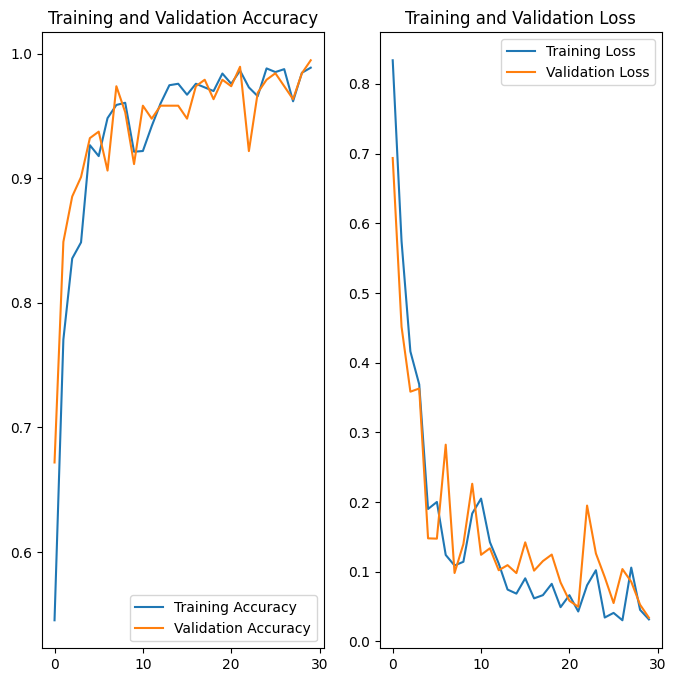

In [38]:
# Accuracy 
plt.figure(figsize=(8,8))
plt.subplot(1, 2, 1)
plt.plot(range(EPOCHS), acc, label="Training Accuracy")
plt.plot(range(EPOCHS), val_acc, label="Validation Accuracy")
plt.legend(loc="lower right")
plt.title("Training and Validation Accuracy")

# LOSS
plt.subplot(1, 2, 2)
plt.plot(range(EPOCHS), loss, label="Training Loss")
plt.plot(range(EPOCHS), val_loss, label="Validation Loss")
plt.legend(loc="upper right")
plt.title("Training and Validation Loss")
plt.show()

First image to predict
actual label :  Potato___Late_blight
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 588ms/step
Predicted label :  Potato___Late_blight


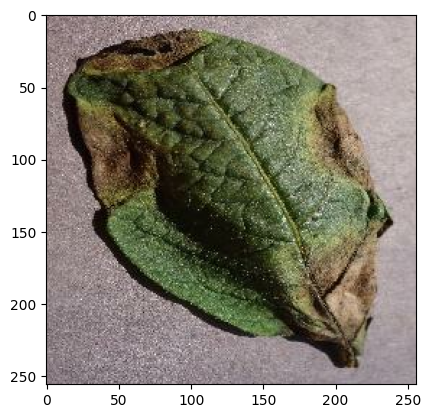

In [39]:
for image_batch, label_batch in test_ds.take(1):
    # plt.imshow(image_batch[0].numpy().astype('uint8'))
    first_image = image_batch[0].numpy().astype('uint8')
    first_label = label_batch[0].numpy()
    
    print("First image to predict")
    plt.imshow(first_image)
    print("actual label : ",class_names[first_label])

    # Let get the predicted class fri for first img
    batch_prediction = model.predict(image_batch)  # Output is a 3 values list, choose max probability
    prediction_class_val = np.argmax(batch_prediction[0])
    pred_class = class_names[prediction_class_val]
    print("Predicted label : ",pred_class)

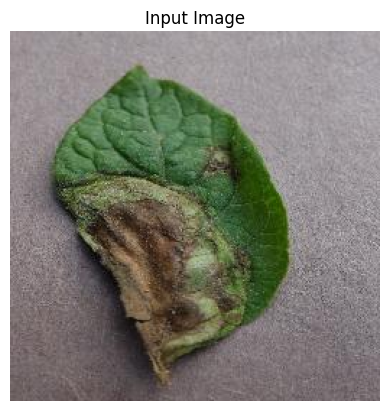

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
Predicted label: Potato___Early_blight
Confidence: 0.99549294


In [57]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array

# path to single image
img_path = "data/Potato___Late_blight/2b974785-090d-4dae-81a2-ce3ebc2a1c68___RS_LB 4634.jpg"

# 1. Load image
img = load_img(img_path, target_size=(256, 256))

# 2. Convert to array
img_array = img_to_array(img).astype("float32") / 255.0

# 3. Add batch dimension
img_batch = np.expand_dims(img_array, axis=0)

# 4. Show image
plt.imshow(img_array)
plt.title("Input Image")
plt.axis("off")
plt.show()

# 5. Predict
prediction = model.predict(img_batch)

# 6. Get class
pred_index = np.argmax(prediction[0])
pred_class = class_names[pred_index]

print("Predicted label:", pred_class)
print("Confidence:", np.max(prediction[0]))

### Function for prediction

In [40]:
# Takes : a trained model & one image
# Returns : predicted class & confidence %
# Since CNN models are designed to process BATCHES of images not single raw images 
# we have to create fake batch using even for one image to get predictoin for that single image

def predict_func(model, img):
    # Converts image into numerical array (tensor values / pixel matrix)
    img_array = tf.keras.preprocessing.image.img_to_array(img)

    # Add batch dimension bcs CNN expects : (batch, height, width, channels), But one image is (height, width, channels) so this will add
    # (256,256,3) >>> (1,256,256,3) : batch size becomes 1
    img_array = tf.expand_dims(img_array, 0)

    # result in format [[a, b, c]], 0 < a, b, c < 1
    preds = model.predict(img_array)

    # find highest probability class
    predicted_class = class_names[np.argmax(preds[0])]

    # How sure the model is about its prediction
    confidence = round(100*(np.max(preds[0])), 2)

    return predicted_class, confidence

In [61]:
for images, labels in test_ds.take(1):
    print(images.numpy().min(), images.numpy().max())

0.0 255.0


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


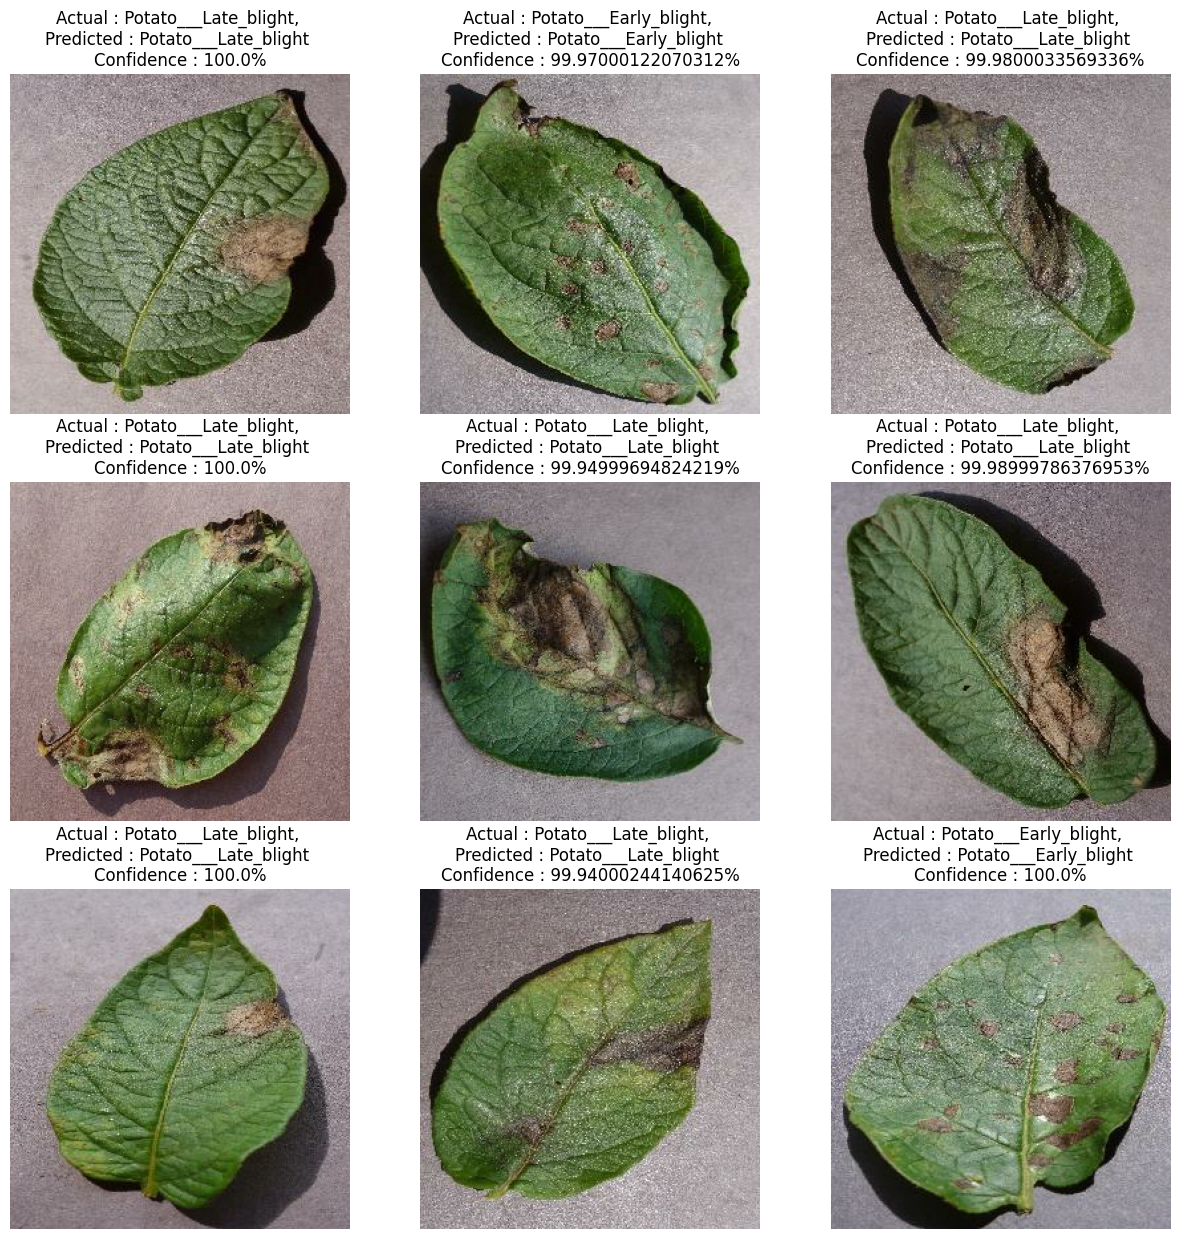

In [62]:
plt.figure(figsize=(15, 15))

# Let get first batch of images in test_ds
for images, labels in test_ds.take(1):

    # consider only 9 images in the batch
    for i in range(9):
        # define the place in the figure
        ax = plt.subplot(3, 3, i+1)
        plt.imshow(images[i].numpy().astype('uint8'))

        predicted_class, confidence = predict_func(model, images[i].numpy())
        actual_class = class_names[labels[i]]

        plt.title(f"Actual : {actual_class}, \nPredicted : {predicted_class} \nConfidence : {confidence}%")
        plt.axis('off')

### Save the models

In [42]:
# Newer Keras versions require a file extension when saving models
'''
model_version = 1
model.save(f"../saved_models/{model_version}.keras")
'''
# TensorFlow SavedModel format
# model.export(f"../models/{model_version}")

'\nmodel_version = 1\nmodel.save(f"../saved_models/{model_version}.keras")\n'

#### Auto define the model verison as int values

In [44]:
import os

dirs = []

for i in os.listdir("../saved_models"):
    first_char = list(i)[0]
    if first_char.isdigit():
        val = int(first_char)
        dirs.append(val)
        
model_version = max (dirs) + 1 # get the current max, then increase by 1
model.save(f"../saved_models/{model_version}.keras")
print("Model new version : ", model_version)

Model new version :  8


### Exporting
##### Instead of saving as name.keras we can use exporting as dir, Inn TF Serving thery expect the dir format

In [50]:
dirs = []

for i in os.listdir("../saved_models/export"):
    first_char = list(i)[0]
    if first_char.isdigit():
        val = int(first_char)
        dirs.append(val)
        
model_version = max (dirs) + 1 # get the current max, then increase by 1 
model.export(f"../saved_models/export/{model_version}")
print("Model new version : ", model_version)

INFO:tensorflow:Assets written to: ../saved_models/export/1\assets


INFO:tensorflow:Assets written to: ../saved_models/export/1\assets


Saved artifact at '../saved_models/export/1'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name='keras_tensor_54')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  2139886377920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2139886378976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2140035391984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2140035388816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2140035124912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2140035124032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2140035130896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2140035126848: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2140035132304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2140035130368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2140035130016: TensorSp

In [38]:
print(tf.__version__)

2.21.0
